# Bike Sales EDA

## 1. Business Context

**Client:**  
An international bike retailer wants to improve marketing and sales efforts by analyzing demographic and behavioral data of its customers.

**Business Goal:**  
Understand which types of customers are more likely to purchase bikes, and what factors influence their purchasing behavior.

**Role of Data Science:**  
We are hired to perform exploratory data analysis (EDA) to extract actionable insights from their customer database.

---


In [ ]:
# Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Bike Sales Sheet.xlsx", sheet_name="bike_buyers")

df.head()

,ID,Marriedarital Singletatus,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Age brachets,Purchased Bike
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,invalid,No
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,invalid,No
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,invalid,No
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,more than 10 miles,Pacific,41,invalid,Yes
4,25597,Single,Male,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,invalid,Yes


## 3. Data Exploration

- Check missing values
- Fix data types
- Review distributions


In [ ]:
df.info()
df.describe(include='all')
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1026 entries, 0 to 1025
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         1026 non-null   int64 
 1   Marriedarital Singletatus  1026 non-null   object
 2   Gender                     1026 non-null   object
 3   Income                     1026 non-null   int64 
 4   Children                   1026 non-null   int64 
 5   Education                  1026 non-null   object
 6   Occupation                 1026 non-null   object
 7   Home Owner                 1026 non-null   object
 8   Cars                       1026 non-null   int64 
 9   Commute Distance           1026 non-null   object
 10  Region                     1026 non-null   object
 11  Age                        1026 non-null   int64 
 12  Age brachets               1026 non-null   object
 13  Purchased Bike             1026 non-null   object
dtypes: int64

,0
ID,0
Marriedarital Singletatus,0
Gender,0
Income,0
Children,0
Education,0
Occupation,0
Home Owner,0
Cars,0
Commute Distance,0


## 4. Data Preprocessing

### Steps:
- Rename messy columns
- Drop invalid columns
- Convert appropriate types


In [ ]:

df.columns = [
    "ID", "Marital_Status", "Gender", "Income", "Children", "Education",
    "Occupation", "Home_Owner", "Cars", "Commute_Distance", "Region", "Age",
    "Age_Bracket", "Purchased_Bike"
]


df = df.drop(columns=['Age_Bracket'])


df['Purchased_Bike'] = df['Purchased_Bike'].map({'Yes': 1, 'No': 0})


df.head()


,ID,Marital_Status,Gender,Income,Children,Education,Occupation,Home_Owner,Cars,Commute_Distance,Region,Age,Purchased_Bike
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,0
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,43,0
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,0
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,more than 10 miles,Pacific,41,1
4,25597,Single,Male,30000,0,Bachelors,Clerical,No,0,0-1 Miles,Europe,36,1


##  Explanatory Business Questions

###  What percentage of customers purchased a bike?


In [ ]:
purchase_rate = df['Purchased_Bike'].mean()
print(f"Bike Purchase Rate: {purchase_rate:.2%}")


Bike Purchase Rate: 48.25%


###  Does marital status affect bike purchases?


Text(0.5, 1.0, 'Bike Purchase Rate by Marital Status')

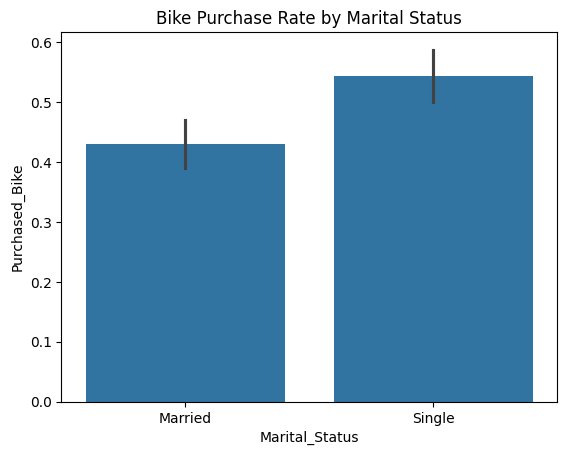

In [ ]:
sns.barplot(x="Marital_Status", y="Purchased_Bike", data=df)
plt.title("Bike Purchase Rate by Marital Status")


### Q3: What is the average income of bike buyers vs non-buyers?


In [ ]:
df.groupby('Purchased_Bike')['Income'].mean()


,Income
Purchased_Bike,
0,55028.248588
1,57474.747475


### Q4: Does education level influence the likelihood of buying a bike?


Text(0.5, 1.0, 'Bike Purchase Rate by Education Level')

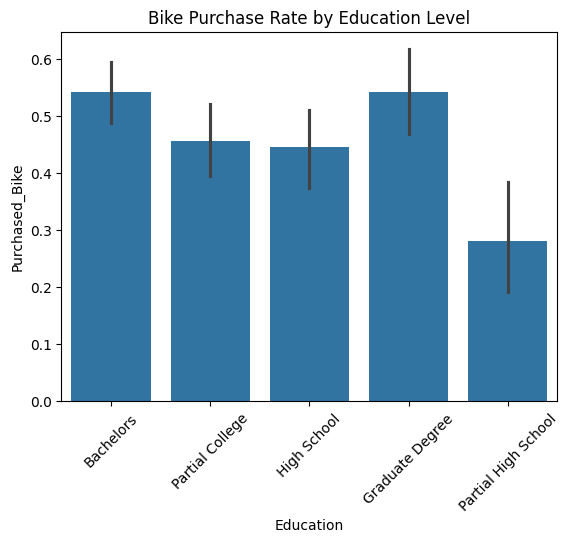

In [ ]:
edu_order = df['Education'].value_counts().index
sns.barplot(x="Education", y="Purchased_Bike", data=df, order=edu_order)
plt.xticks(rotation=45)
plt.title("Bike Purchase Rate by Education Level")


###  Which occupations are most likely to buy bikes?


Text(0.5, 1.0, 'Purchase Rate by Occupation')

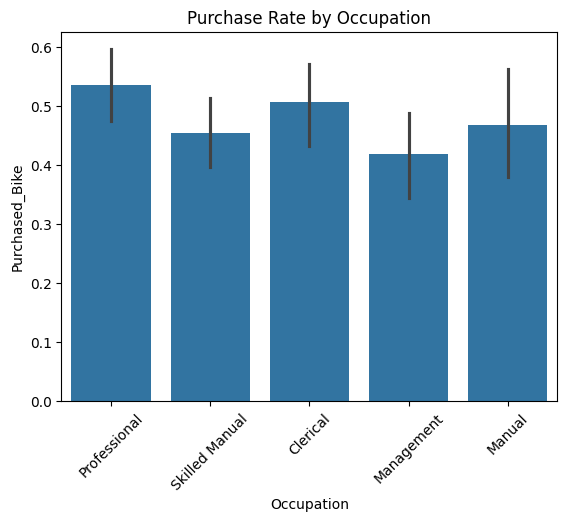

In [ ]:
occ_order = df['Occupation'].value_counts().index
sns.barplot(x="Occupation", y="Purchased_Bike", data=df, order=occ_order)
plt.xticks(rotation=45)
plt.title("Purchase Rate by Occupation")


Is there a relationship between income and age among buyers?

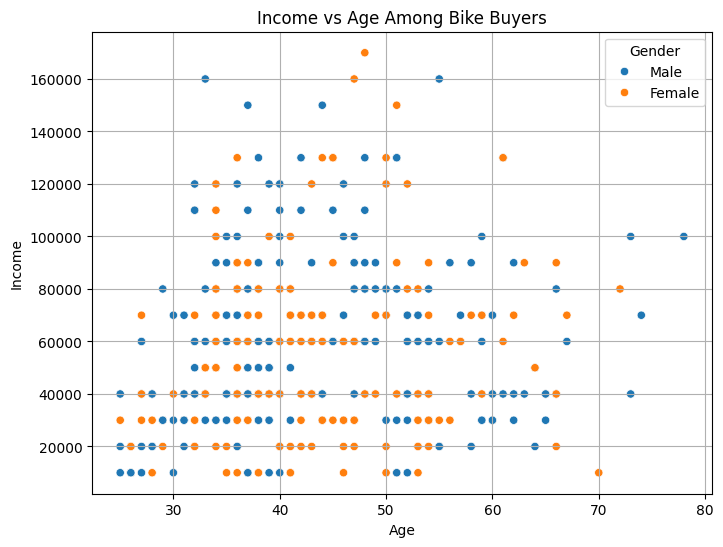

In [ ]:
buyers = df[df['Purchased_Bike'] == 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Income', data=buyers, hue='Gender')
plt.title('Income vs Age Among Bike Buyers')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True)
plt.show()


###  How does commute distance impact bike purchases?


Text(0.5, 1.0, 'Bike Purchase Rate by Commute Distance')

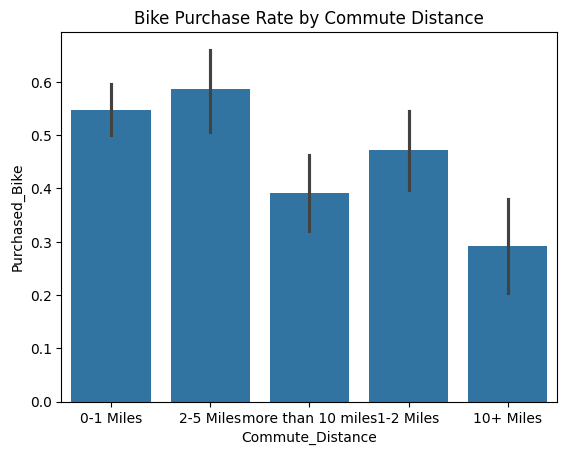

In [ ]:
sns.barplot(x="Commute_Distance", y="Purchased_Bike", data=df)
plt.title("Bike Purchase Rate by Commute Distance")


What is the distribution of customers by region?

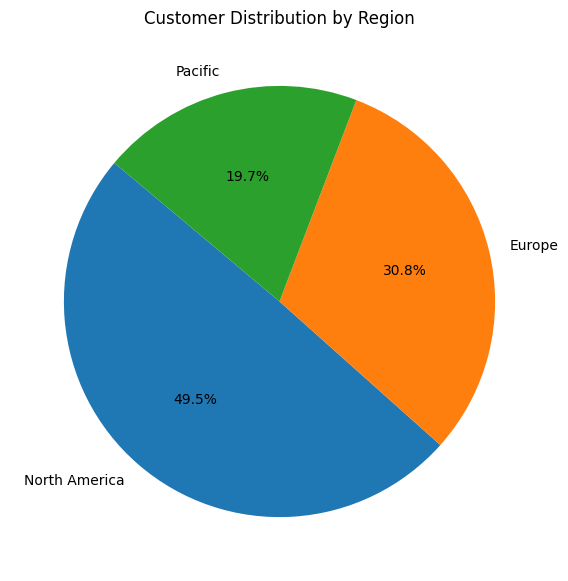

In [ ]:
region_counts = df['Region'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Customer Distribution by Region')
plt.show()


 What is the correlation between numeric features?

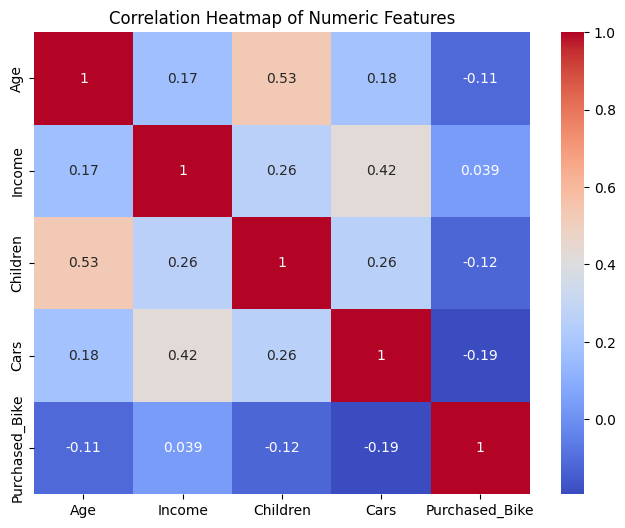

In [ ]:
# Select numeric features
numeric_cols = df[['Age', 'Income', 'Children', 'Cars', 'Purchased_Bike']]

# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


###  Which regions have higher purchase rates?


Text(0.5, 1.0, 'Purchase Rate by Region')

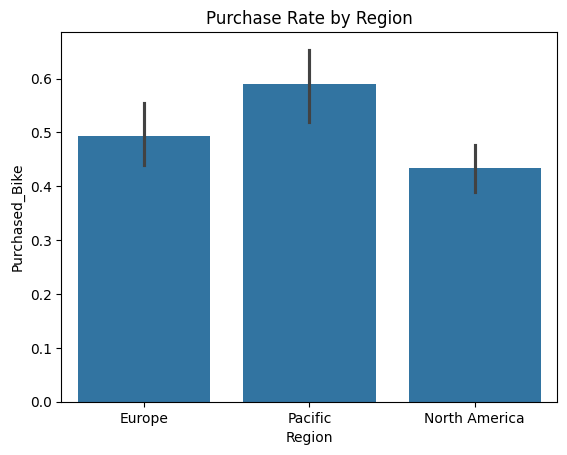

In [ ]:
sns.barplot(x="Region", y="Purchased_Bike", data=df)
plt.title("Purchase Rate by Region")


###  How does the number of children affect bike buying?


Text(0.5, 1.0, 'Purchase Rate by Number of Children')

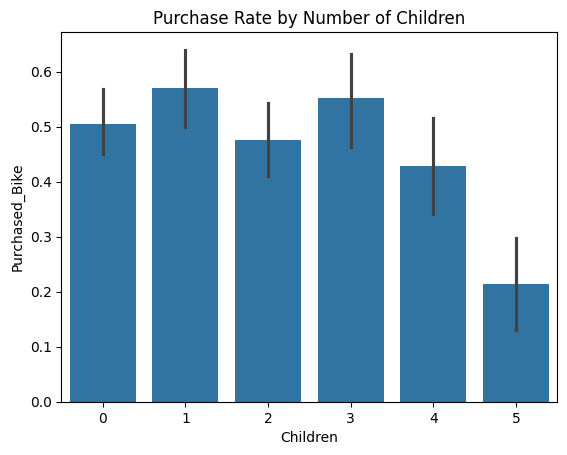

In [ ]:
sns.barplot(x="Children", y="Purchased_Bike", data=df)
plt.title("Purchase Rate by Number of Children")


###  What role does age play in purchasing a bike?


Text(0.5, 1.0, 'Age Distribution by Purchase')

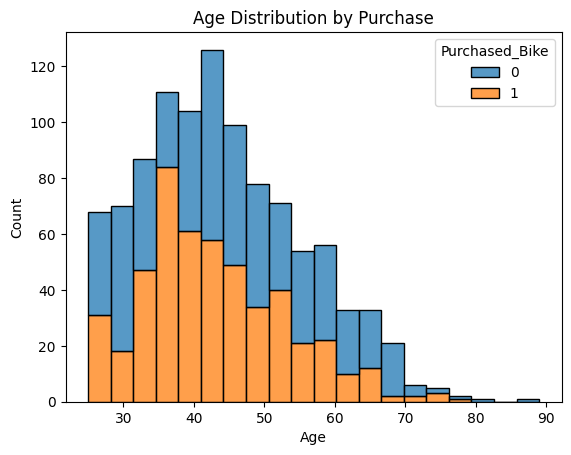

In [ ]:
sns.histplot(data=df, x="Age", hue="Purchased_Bike", multiple="stack", bins=20)
plt.title("Age Distribution by Purchase")


###  Do homeowners buy bikes more often than non-homeowners?


Text(0.5, 1.0, 'Bike Purchase Rate by Home Ownership')

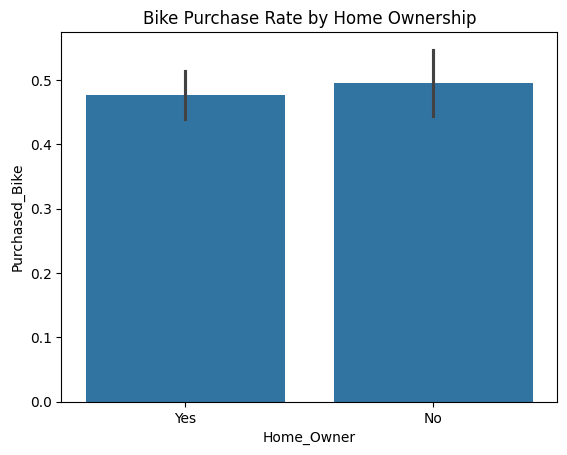

In [ ]:
sns.barplot(x="Home_Owner", y="Purchased_Bike", data=df)
plt.title("Bike Purchase Rate by Home Ownership")


##  Final Insights & Recommendations

### Summary of Insights:
- Married individuals tend to buy more bikes than singles.
- Higher education and professional occupations correlate with higher purchase rates.
- Short commute distances are linked with more purchases.
- People with higher income and fewer children are more likely to purchase.
- Homeowners and residents in certain regions (like Pacific) are stronger buyers.

### Recommendations:
- **Marketing:** Focus campaigns on professionals and married individuals.
- **Product Placement:** Target regions with high purchase rates.
- **Cross-sell:** Suggest bikes to those with short commutes or who own no car.
- **Retention:** Consider loyalty programs for high-income customers.

---
